# Telecom Churn Prediction

Supervised machine learning pipeline for predicting telecom customer churn

## Process steps

### Preprocessing
- Loading and inspecting data
- Cleaning and transforming columns
- Transformation of categorical variables
### Imbalance handling
- Imbalance handling: SMOTE and class-weight
### Modelling
- Models: k-NN, MLP (Neural Network), Decision Tree, AdaBoost
- Hyperparameter tuning with GridSearch (StratifiedKFold)
### Evaluation
- Final evaluation on held-out test set
- Visualizations (confusion matrix, ROC, precision-recall)
- Feature importance & SHAP explainability

### Requirements
Install required packages before running:



In [5]:
# ---------------------------
# Imports
# ---------------------------
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ---------------------------
# Constants
# ---------------------------
RANDOM_STATE = 42 # determinisitc, reproducable results
CV_FOLDS = 5 # k-fold cross validation
DATA_PATH = "/Users/soenkekraft/Documents/UPM_Madrid/1_Semester/Data Processes/Project/Project 2/Cernavca_Kraft/WA_Fn-UseC_-Telco-Customer-Churn.csv"


## Load and display dataset

assess initial dataset and identify needs for data preprocessing

In [6]:
# ---------------------------
# Load dataset
# ---------------------------

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Preprocessing

To prepare the dataset for the modelling, the following preprocessing steps are performed:

1. **Convert categorical variables to numeric** using one-hot encoding.  
2. **Handle missing or inconsistent data** (NaNs, invalid entries, whitespace, etc.).  
3. **Standardize the dataset** 

### Column-wise Transformations

| Column / Type                     | Original Type / Values                                     | Transformation / Notes                                                                 |
|----------------------------------|-----------------------------------------------------------|---------------------------------------------------------------------------------------|
| `customerID`                      | String / Unique ID                                        | Client identifier, not used as a feature                                                      |
| `TotalCharges`                    | Object / String                                           | impute missing values                             |
| `tenure`                          | Numeric (int/float)                                      | impute missing values                                            |
| `MonthlyCharges`                  | Numeric (float)                                          | impute missing values                                            |
| Binary service columns (`Yes`/`No` / `No phone service`) | Object (`Yes`/`No`, `No phone service`)                 | `No phone service` / `No internet service` → `No`, then mapped `Yes`→1, `No`→0      |
| `gender`                          | Object (`Male` / `Female`)                               | Mapped `Male`→0, `Female`→1                                                        |
| Other categorical columns         | Object / Strings                                         | One-hot encoded: each category becomes a separate 0/1 column         |
| `Churn` (target)                  | Object (`Yes` / `No`)    | mapped to 0/1 in `ChurnFlag`          |

**Outout of preprocessing:** The dataset is now **fully numeric**, with all categorical variables encoded, and ready for train/test splitting and machine learning models.


In [7]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Silence future downcasting warning
pd.set_option('future.no_silent_downcasting', True)

# ---------------------------
# Drop identifier column from predictors
# ---------------------------
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# ---------------------------
# Normalize Yes/No columns → 0/1
# ---------------------------
yes_no_cols = [
    'Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','PaperlessBilling','Churn'
]

for c in yes_no_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower()
        df[c] = df[c].replace({'yes': 1, 'no': 0})

# ---------------------------
# Map gender to 0/1
# ---------------------------
if 'gender' in df.columns:
    df['gender'] = (
        df['gender']
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'male': 0, 'female': 1})
    )

# ---------------------------
# Ensure numeric columns are numeric and fill missing values
# ---------------------------
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

for num_col in numeric_cols:
    if num_col in df.columns:
        df[num_col] = pd.to_numeric(df[num_col], errors='coerce')
        df[num_col] = df[num_col].fillna(df[num_col].median())

# ---------------------------
# Normalize service columns
# (No phone service / No internet service → 0)
# ---------------------------
service_cols = [
    'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

for c in service_cols:
    if c in df.columns:
        df[c] = df[c].replace({
            'no phone service': 0,
            'no internet service': 0
        })

# ---------------------------
# One-hot encode remaining categorical columns
# ---------------------------
exclude_cols = (
    numeric_cols
    + ['gender', 'Churn']
    + [c for c in df.columns if df[c].dropna().isin([0, 1]).all()]
)

categorical_cols = [
    c for c in df.columns
    if df[c].dtype == 'object' and c not in exclude_cols
]

if categorical_cols:
    import sklearn
    sklearn_version = tuple(map(int, sklearn.__version__.split('.')[:2]))

    if sklearn_version >= (1, 2):
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    else:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

    cat_encoded = ohe.fit_transform(df[categorical_cols])

    cat_columns_ohe = []
    for i, col in enumerate(categorical_cols):
        cat_columns_ohe.extend(
            [f"{col}__{str(cat)}" for cat in ohe.categories_[i]]
        )

    df_cat = pd.DataFrame(
        cat_encoded,
        columns=cat_columns_ohe,
        index=df.index
    )

    df = pd.concat(
        [df.drop(columns=categorical_cols), df_cat],
        axis=1
    )

# ---------------------------
# Create target column
# ---------------------------
df['ChurnFlag'] = df['Churn'].astype('Int64')
df = df.drop(columns=['Churn'])

# ---------------------------
# Final checks
# ---------------------------
print("Preprocessing complete.")
print("Number of rows:", len(df))
print("Number of features:", df.shape[1] - 1)
print("Target distribution:")
print(df['ChurnFlag'].value_counts(normalize=True))
display(df.head())

print("Feature columns:")
print(df.columns.tolist())



Preprocessing complete.
Number of rows: 7043
Number of features: 26
Target distribution:
ChurnFlag
0    0.73463
1    0.26537
Name: proportion, dtype: Float64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService__Fiber optic,InternetService__No,Contract__Month-to-month,Contract__One year,Contract__Two year,PaymentMethod__Bank transfer (automatic),PaymentMethod__Credit card (automatic),PaymentMethod__Electronic check,PaymentMethod__Mailed check,ChurnFlag
0,1,0,1,0,1,0,0,0,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
1,0,0,0,0,34,1,0,1,0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
2,0,0,0,0,2,1,0,1,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,0,0,0,0,45,0,0,1,0,1,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0
4,1,0,0,0,2,1,0,0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService__DSL', 'InternetService__Fiber optic', 'InternetService__No', 'Contract__Month-to-month', 'Contract__One year', 'Contract__Two year', 'PaymentMethod__Bank transfer (automatic)', 'PaymentMethod__Credit card (automatic)', 'PaymentMethod__Electronic check', 'PaymentMethod__Mailed check', 'ChurnFlag']


## Check Class imbalance

In [8]:
churn_ratio = df['ChurnFlag'].value_counts(normalize=True).rename(index={0:'No',1:'Yes'})
print("Churn class proportions:")
print(churn_ratio)

Churn class proportions:
ChurnFlag
No     0.73463
Yes    0.26537
Name: proportion, dtype: Float64


## Summary statistics

Dataset shape: (7043, 27)

Data types:


gender                                        int64
SeniorCitizen                                 int64
Partner                                      object
Dependents                                   object
tenure                                        int64
PhoneService                                 object
MultipleLines                                object
OnlineSecurity                               object
OnlineBackup                                 object
DeviceProtection                             object
TechSupport                                  object
StreamingTV                                  object
StreamingMovies                              object
PaperlessBilling                             object
MonthlyCharges                              float64
TotalCharges                                float64
InternetService__DSL                        float64
InternetService__Fiber optic                float64
InternetService__No                         float64
Contract__Mo

,count,mean,std,min,25%,50%,75%,max,missing_values
gender,7043.0,0.495244,0.500013,0.0,0.0,0.0,1.0,1.0,0
SeniorCitizen,7043.0,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0,0
tenure,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0,0
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75,0
TotalCharges,7043.0,2281.916928,2265.270398,18.8,402.225,1397.475,3786.6,8684.8,0
InternetService__DSL,7043.0,0.343746,0.474991,0.0,0.0,0.0,1.0,1.0,0
InternetService__Fiber optic,7043.0,0.439585,0.496372,0.0,0.0,0.0,1.0,1.0,0
InternetService__No,7043.0,0.216669,0.412004,0.0,0.0,0.0,0.0,1.0,0
Contract__Month-to-month,7043.0,0.550192,0.49751,0.0,0.0,1.0,1.0,1.0,0
Contract__One year,7043.0,0.209144,0.406726,0.0,0.0,0.0,0.0,1.0,0



Class distribution (absolute):


ChurnFlag
0    5174
1    1869
Name: count, dtype: Int64


Class distribution (relative):


ChurnFlag
0    0.73463
1    0.26537
Name: proportion, dtype: Float64

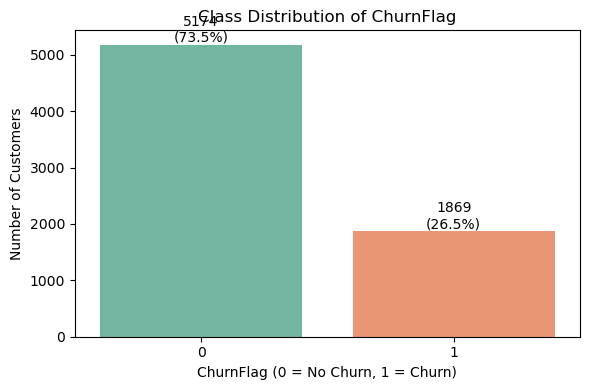

In [9]:
# ============================================================
# Exploratory Summary Statistics and Class Distribution
# (Before Train–Test Split)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Basic dataset information
# ---------------------------
print("Dataset shape:", df.shape)
print("\nData types:")
display(df.dtypes)

# ---------------------------
# Summary statistics for numerical features
# ---------------------------
summary_stats = df.describe().T
summary_stats['missing_values'] = df.isna().sum()
display(summary_stats)

# ---------------------------
# Target variable distribution
# ---------------------------
print("\nClass distribution (absolute):")
display(df['ChurnFlag'].value_counts())

print("\nClass distribution (relative):")
display(df['ChurnFlag'].value_counts(normalize=True))

# ---------------------------
# Plot class distribution
# ---------------------------
plt.figure(figsize=(6, 4))

sns.countplot(
    x='ChurnFlag',
    hue='ChurnFlag',
    data=df,
    palette='Set2',
    legend=False
)


plt.title('Class Distribution of ChurnFlag')
plt.xlabel('ChurnFlag (0 = No Churn, 1 = Churn)')
plt.ylabel('Number of Customers')

# Annotate bars with counts and percentages
total = len(df)
for p in plt.gca().patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    plt.text(
        p.get_x() + p.get_width() / 2,
        p.get_height(),
        f'{count}\n({percentage:.1f}%)',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


## Split in Train and Testing

- Separation of predictors and target variable.

- A test size of 0.2 is specified, meaning that 20% of the observations are reserved for final model evaluation, while the remaining 80% are used for model training and validation

- The split is performed using stratification with respect to the target variable (stratify=y). Stratification ensures that the proportion of churned and non-churned customers is preserved in both the training and test sets

## Feature subset selection using Filter methods (optional)

Select the feature subset based on 2 step approach:

- mutual_info: for selecting relevant feature for expaling the target
- correlation: to identify redundancies among these features

USER INPUT required to define feature subsets:

- TOP_K_FEATURES = 26          # select feature to be kepy
- CORR_THRESHOLD = 0.9         # redundancy threshold cor correlation analysis


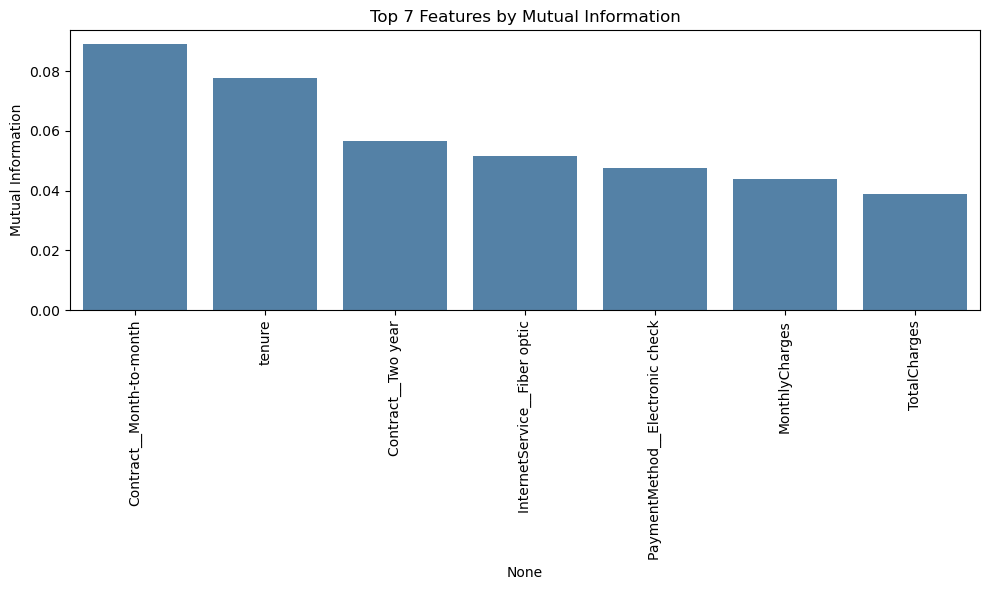

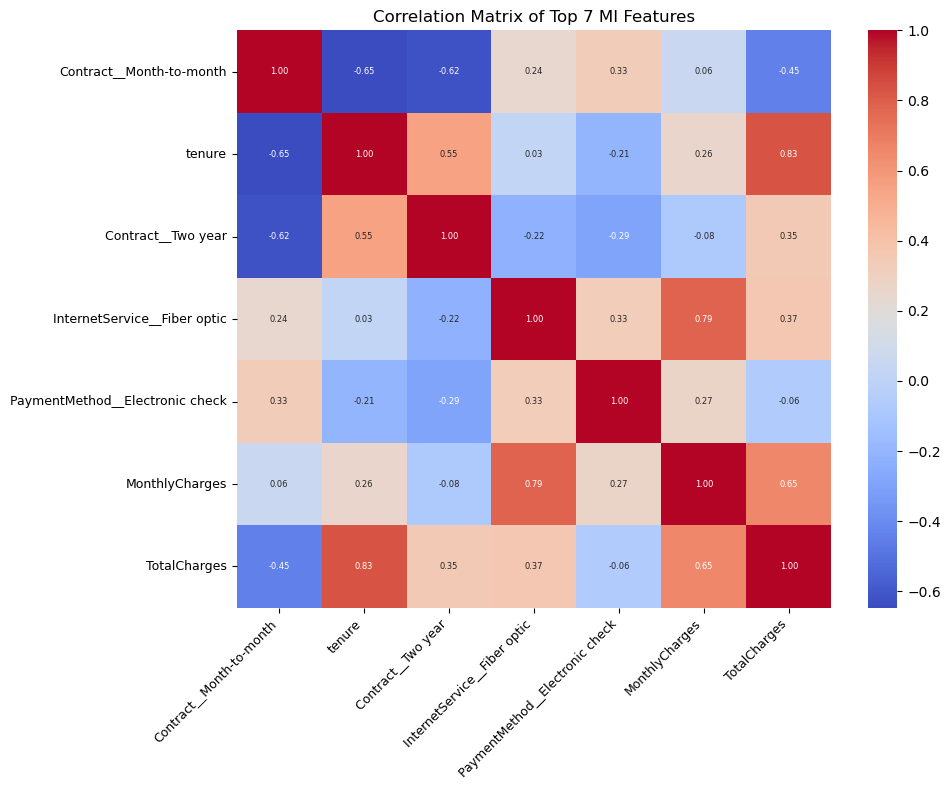

<Figure size 640x480 with 0 Axes>

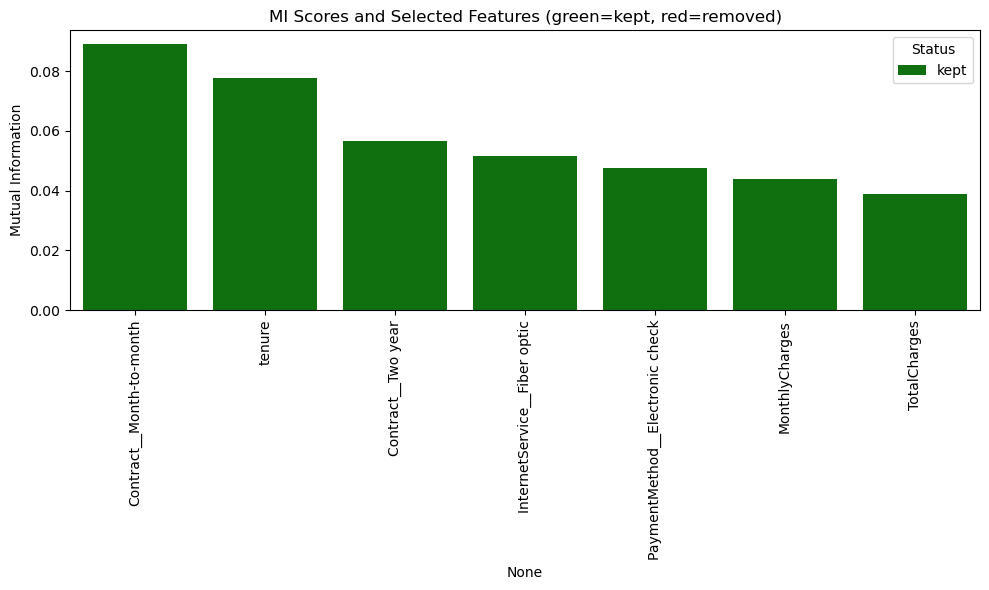

Features after MI screening: 7
Features after redundancy removal: 7
Selected features:
['Contract__Month-to-month', 'tenure', 'Contract__Two year', 'InternetService__Fiber optic', 'PaymentMethod__Electronic check', 'MonthlyCharges', 'TotalCharges']

Reduced training set shape: (5634, 7)
Reduced test set shape: (1409, 7)


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# USER SETTINGS
# ---------------------------
TOP_K_FEATURES = 7          # initial MI-based screening
CORR_THRESHOLD = 0.9         # redundancy threshold
RANDOM_STATE = 42

# ---------------------------
# Separate features and target
# ---------------------------
X = df.drop(columns=['ChurnFlag'])
y = df['ChurnFlag']

# ---------------------------
# Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# ---------------------------
# STEP 1: Mutual Information (Relevance)
# ---------------------------
mi = mutual_info_classif(X_train, y_train, discrete_features='auto', random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=X_train.columns).sort_values(ascending=False)

# Select top-K by MI
top_features = mi_scores.head(TOP_K_FEATURES).index.tolist()

# ---------------------------
# STEP 2: Correlation-based redundancy removal
# ---------------------------
X_mi = X_train[top_features]
corr_matrix = X_mi.corr().abs()

selected_features = []
for feature in top_features:
    if not any(corr_matrix.loc[feature, selected_features] > CORR_THRESHOLD):
        selected_features.append(feature)

# ---------------------------
# Reduce datasets
# ---------------------------
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# ---------------------------
# PLOT 1: Mutual Information Scores
# ---------------------------
plt.figure(figsize=(10,6))
sns.barplot(
    x=mi_scores.index[:TOP_K_FEATURES],
    y=mi_scores.values[:TOP_K_FEATURES],
    color="steelblue"
)
plt.xticks(rotation=90)
plt.ylabel("Mutual Information")
plt.title(f"Top {TOP_K_FEATURES} Features by Mutual Information")
plt.tight_layout()
plt.show()

# ---------------------------
# PLOT 2: Correlation heatmap of top features
# ---------------------------
plt.figure(figsize=(10,8))
sns.heatmap(
    X_mi.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    annot_kws={"size": 6},  # reduce text size
    xticklabels=True,
    yticklabels=True
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title(f"Correlation Matrix of Top {TOP_K_FEATURES} MI Features", fontsize=12)
plt.tight_layout()
plt.show()

# Save the correlation heatmap as a PNG figure
plt.savefig("correlation_heatmap_top_features.png", dpi=300)  # dpi=300 for high resolution
plt.show()

# ---------------------------
# PLOT 3: Selected features vs MI
# ---------------------------
plt.figure(figsize=(10,6))
mi_subset = mi_scores[top_features]
feature_status = ['kept' if f in selected_features else 'removed' for f in top_features]

sns.barplot(
    x=mi_subset.index,
    y=mi_subset.values,
    hue=feature_status,
    dodge=False,
    palette={'kept':'green','removed':'red'}
)
plt.xticks(rotation=90)
plt.ylabel("Mutual Information")
plt.title(f"MI Scores and Selected Features (green=kept, red=removed)")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

# ---------------------------
# Final outputs
# ---------------------------
print(f"Features after MI screening: {len(top_features)}")
print(f"Features after redundancy removal: {len(selected_features)}")
print("Selected features:")
print(selected_features)

print("\nReduced training set shape:", X_train.shape)
print("Reduced test set shape:", X_test.shape)


## Supervised classification

Definition of several calssifiers. Use of the SMOTE approach to tackle with class imbalance.

### Classifiers

The used classifiers are:

- dt_base  = DecisionTreeClassifier(random_state=RANDOM_STATE)
- knn_base = KNeighborsClassifier()
- mlp_base = MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
- ada_base = AdaBoostClassifier(random_state=RANDOM_STATE)

SMOTE (Synthetic Minority Oversampling Technique) used to balance classes by generating synthetic samples for the minority classes.

StandardScaler: Scales features for distance-based and neural network classifiers.
class_weight='balanced' in Decision Tree ensures it accounts for class imbalance without SMOTE.


In [11]:
# ============================================================
# Classifier Definitions
# ============================================================

# ---------------------------
# Models
# ---------------------------
dt_base  = DecisionTreeClassifier(random_state=RANDOM_STATE)
knn_base = KNeighborsClassifier()
mlp_base = MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
ada_base = AdaBoostClassifier(random_state=RANDOM_STATE)

smote = SMOTE(random_state=RANDOM_STATE)

# ============================================================
# Standard Pipelines (for comparisson)
# ============================================================

# Decision Tree with class weighting (no scaling needed)
pipe_dt_classweight = Pipeline(steps=[
    ('clf', DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

# KNN (scaling required)
pipe_knn = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', knn_base)
])

# MLP (scaling required)
pipe_mlp = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('clf', mlp_base)
])

# AdaBoost (no scaling required)
pipe_ada = Pipeline(steps=[
    ('clf', ada_base)
])

# ============================================================
# SMOTE Pipelines (for imbalance correction) --> to be used
# ============================================================

# Decision Tree + SMOTE
imb_pipe_dt = ImbPipeline(steps=[
    ('smote', smote),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# KNN + SMOTE (scaling before SMOTE)
imb_pipe_knn = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', KNeighborsClassifier())
])

# MLP + SMOTE
imb_pipe_mlp = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', smote),
    ('clf', MLPClassifier(max_iter=1000, random_state=RANDOM_STATE))
])

# AdaBoost + SMOTE
imb_pipe_ada = ImbPipeline(steps=[
    ('smote', smote),
    ('clf', AdaBoostClassifier(random_state=RANDOM_STATE))
])

print("Models are defined.")



Models are defined.


## Hyperparameter assessment

The effet of hyperparameters is analysed for the defined classifiers using deterministic Grid Search: 

- In Grid Search all defined hyperparameter combinations are tested
- Number of defined values must be limited to avoid long computation time
- Values are selected based on experience and litarure
- Values can be modified in the script below


In [12]:
param_grid_dt = {
    'clf__max_depth': [None, 5, 10, 15, 20],
    'clf__min_samples_split': [2, 5, 10]
}

param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
    'clf__weights': ['uniform', 'distance'],
    'clf__p': [1, 2]
}

param_grid_mlp = {
    'clf__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': [1e-4, 1e-3]
}

param_grid_ada = {
    'clf__n_estimators': [50, 100, 200, 500],
    'clf__learning_rate': [0.5, 1.0]
}

pipelines_and_grids = {
    'DT_classweight': (pipe_dt_classweight, param_grid_dt),
    'DT_SMOTE':       (imb_pipe_dt, param_grid_dt),
    'KNN_SMOTE':      (imb_pipe_knn, param_grid_knn),
    'MLP_SMOTE':      (imb_pipe_mlp, param_grid_mlp),
    'ADA_SMOTE':      (imb_pipe_ada, param_grid_ada)
}

print("Pipelines and grids prepared:", list(pipelines_and_grids.keys()))


Pipelines and grids prepared: ['DT_classweight', 'DT_SMOTE', 'KNN_SMOTE', 'MLP_SMOTE', 'ADA_SMOTE']


## Run GridSearch

Run the grid Search over the defined hyperparameters

Use a Stratified K-Fold cross-validation scheme wiht the following setting:

- n_splits=CV_FOLDS: the data is split into K folds (here 5)

- stratified: each fold preserves the original churn / non-churn class proportions

- shuffle=True: the data is randomly shuffled before splitting

- F1-score: harmonic mean of precision and recall



In [13]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = 'f1'  # balanced metric for imbalanced classes

grid_results = {}

for name, (pipeline, param_grid) in pipelines_and_grids.items():
    print(f"\nRunning GridSearchCV for {name}...")
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1
    )
    gs.fit(X_train, y_train)
    grid_results[name] = gs
    
    print(f"Best params for {name}: {gs.best_params_}")
    print(f"Best CV {scoring} for {name}: {gs.best_score_:.4f}")



Running GridSearchCV for DT_classweight...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params for DT_classweight: {'clf__max_depth': 5, 'clf__min_samples_split': 2}
Best CV f1 for DT_classweight: 0.6208

Running GridSearchCV for DT_SMOTE...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params for DT_SMOTE: {'clf__max_depth': 5, 'clf__min_samples_split': 2}
Best CV f1 for DT_SMOTE: 0.6081

Running GridSearchCV for KNN_SMOTE...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params for KNN_SMOTE: {'clf__n_neighbors': 25, 'clf__p': 2, 'clf__weights': 'uniform'}
Best CV f1 for KNN_SMOTE: 0.6233

Running GridSearchCV for MLP_SMOTE...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for MLP_SMOTE: {'clf__activation': 'relu', 'clf__alpha': 0.001, 'clf__hidden_layer_sizes': (50,)}
Best CV f1 for MLP_SMOTE: 0.6253

Running GridSearchCV for ADA_SMOTE...
Fitting 5 folds for each of 8 candidates, totalling 40 fit

## Visualisation of Grid Search results

Plot the F1 score as a function of 1 or 2 parameters 

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_gridsearch_results(gs, model_name, param_x, param_y=None):
    """
    Plot GridSearchCV results.
    
    param_x: str, name of first hyperparameter (e.g. 'param_clf__max_depth')
    param_y: str or None, second hyperparameter for heatmap
    """
    results = pd.DataFrame(gs.cv_results_)

    #Line plot
    if param_y is None:
        plt.figure(figsize=(7, 4))
        sns.lineplot(
            data=results,
            x=param_x,
            y='mean_test_score',
            marker='o'
        )
        plt.title(f"{model_name}: F1-score vs {param_x}")
        plt.ylabel("Mean CV F1-score")
        plt.xlabel(param_x.replace('param_', ''))
        plt.grid(True)
        plt.show()

    #Heatmap
    else:
        pivot = results.pivot_table(
            values='mean_test_score',
            index=param_y,
            columns=param_x
        )
        plt.figure(figsize=(7, 5))
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".3f",
            cmap="viridis"
        )
        plt.title(f"{model_name}: Mean CV F1-score")
        plt.xlabel(param_x.replace('param_', ''))
        plt.ylabel(param_y.replace('param_', ''))
        plt.show()


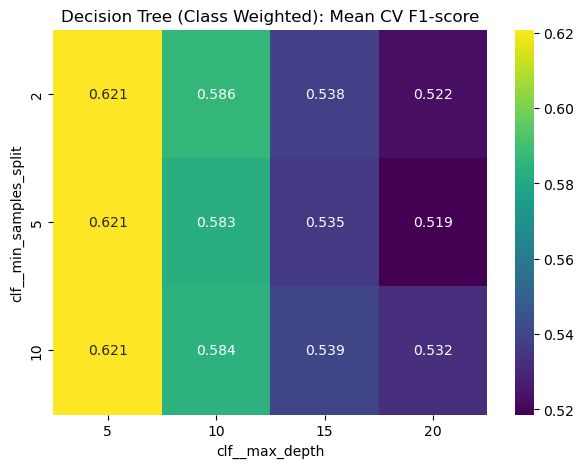

In [15]:
plot_gridsearch_results(
    grid_results['DT_classweight'],
    model_name="Decision Tree (Class Weighted)",
    param_x='param_clf__max_depth',
    param_y='param_clf__min_samples_split'
)


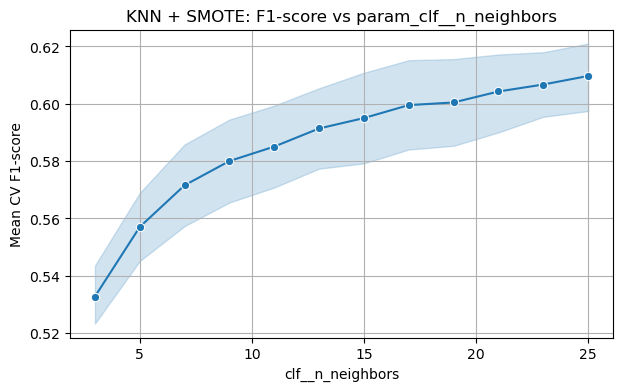

In [16]:
plot_gridsearch_results(
    grid_results['KNN_SMOTE'],
    model_name="KNN + SMOTE",
    param_x='param_clf__n_neighbors'
)


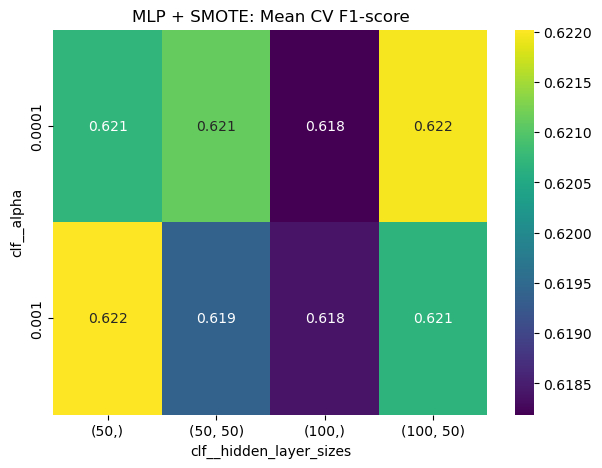

In [17]:
plot_gridsearch_results(
    grid_results['MLP_SMOTE'],
    model_name="MLP + SMOTE",
    param_x='param_clf__hidden_layer_sizes',
    param_y='param_clf__alpha'
)


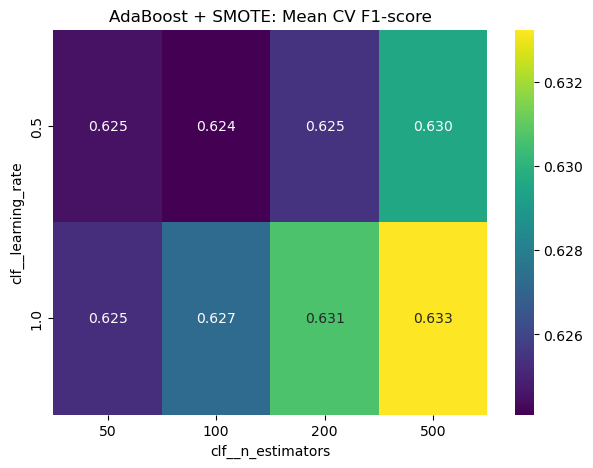

In [18]:
plot_gridsearch_results(
    grid_results['ADA_SMOTE'],
    model_name="AdaBoost + SMOTE",
    param_x='param_clf__n_estimators',
    param_y='param_clf__learning_rate'
)


## Evaluate the best models obtained from grid search

- Uses best hyperparameter configuration obtained from GridSearchCV
- Evaluates the classifier on the test set (not used before)
- Provides ROC, PR curve, confusion matrix, classification report
- Uses probability-based metrics, which is correct for churn


In [19]:
for name, gs in grid_results.items():
    print(f"\nEvaluating {name} on test set...")
    y_pred = gs.best_estimator_.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Evaluating DT_classweight on test set...
              precision    recall  f1-score   support

         0.0       0.92      0.72      0.81      1035
         1.0       0.51      0.82      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

Confusion Matrix:
 [[744 291]
 [ 68 306]]

Evaluating DT_SMOTE on test set...
              precision    recall  f1-score   support

         0.0       0.89      0.76      0.82      1035
         1.0       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
 [[791 244]
 [ 99 275]]

Evaluating KNN_SMOTE on test set...
              precision    recall  f1-score   support

         0.0       0.91      0.71      0.80      1035
         1.0       0.51      0.81     

### Visualisation

Visualisation of the results






==== Evaluating DT_classweight ====


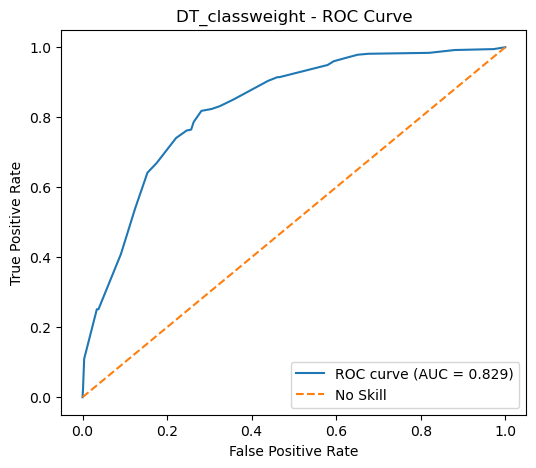

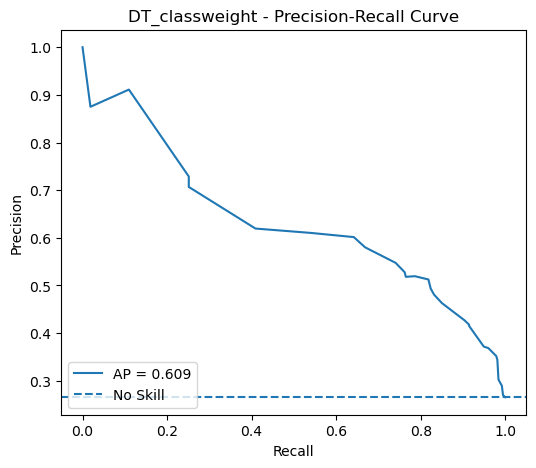

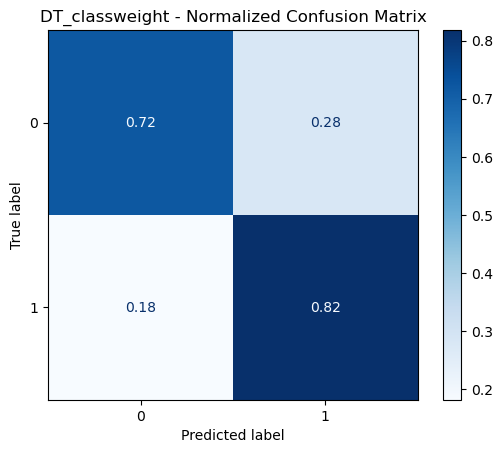

Classification Report:

              precision    recall  f1-score   support

         0.0      0.916     0.719     0.806      1035
         1.0      0.513     0.818     0.630       374

    accuracy                          0.745      1409
   macro avg      0.714     0.769     0.718      1409
weighted avg      0.809     0.745     0.759      1409


==== Evaluating DT_SMOTE ====


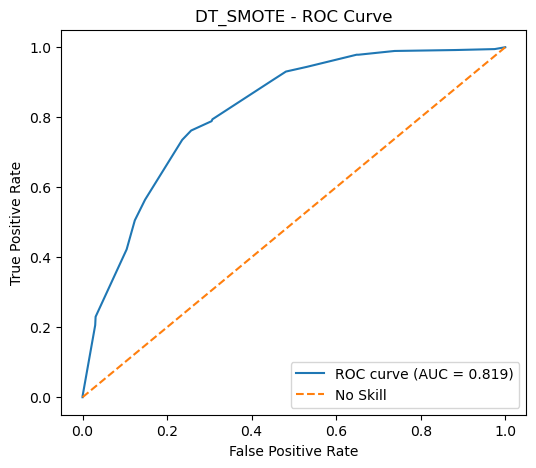

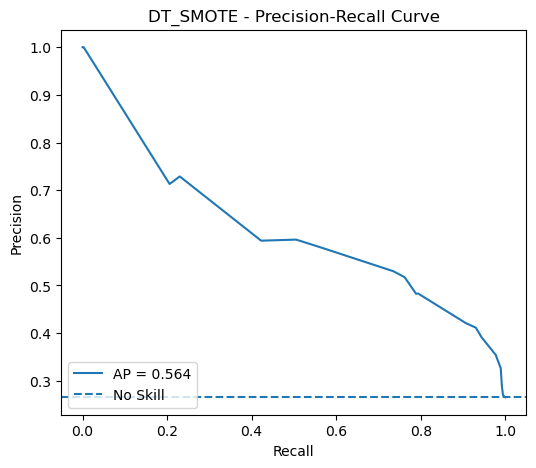

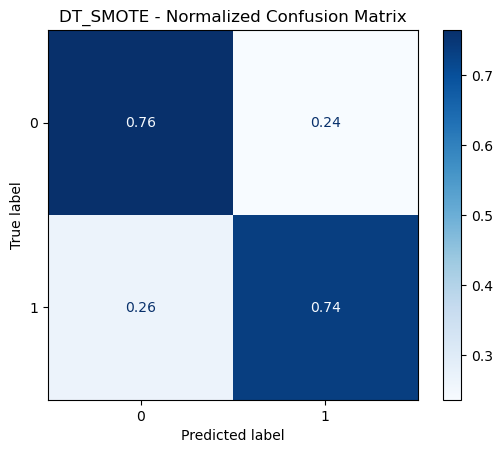

Classification Report:

              precision    recall  f1-score   support

         0.0      0.889     0.764     0.822      1035
         1.0      0.530     0.735     0.616       374

    accuracy                          0.757      1409
   macro avg      0.709     0.750     0.719      1409
weighted avg      0.793     0.757     0.767      1409


==== Evaluating KNN_SMOTE ====


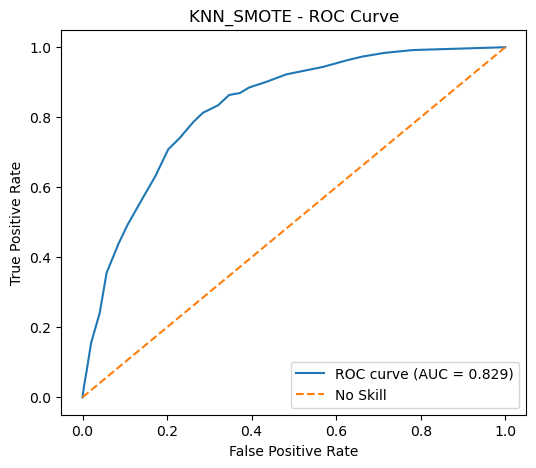

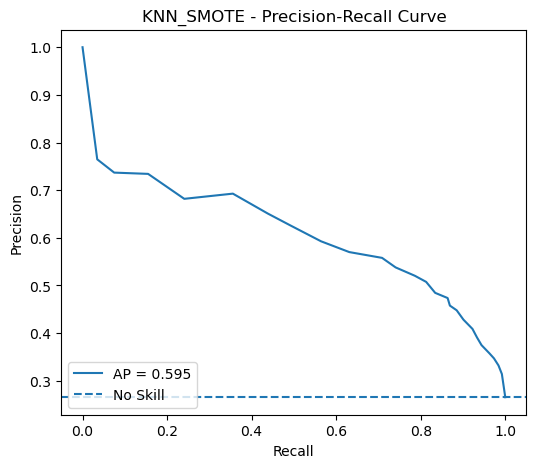

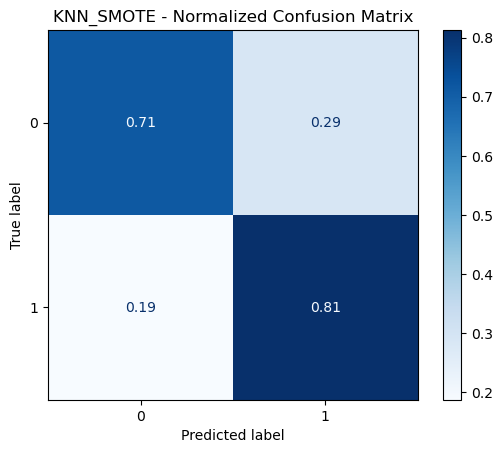

Classification Report:

              precision    recall  f1-score   support

         0.0      0.914     0.715     0.802      1035
         1.0      0.508     0.813     0.625       374

    accuracy                          0.741      1409
   macro avg      0.711     0.764     0.714      1409
weighted avg      0.806     0.741     0.755      1409


==== Evaluating MLP_SMOTE ====


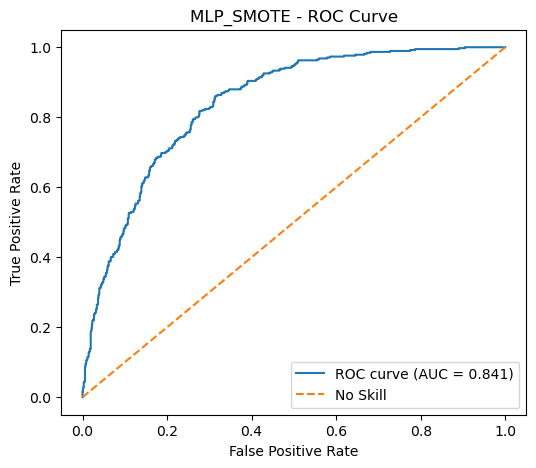

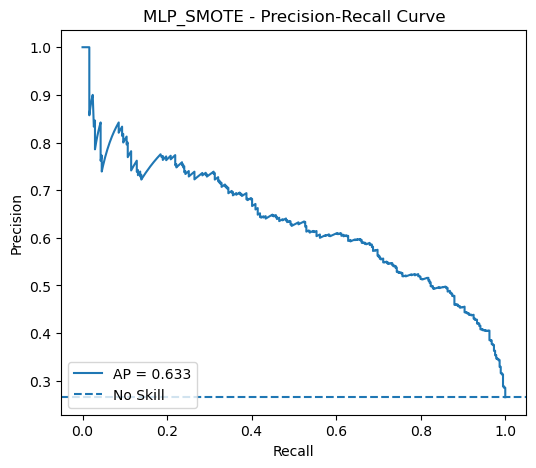

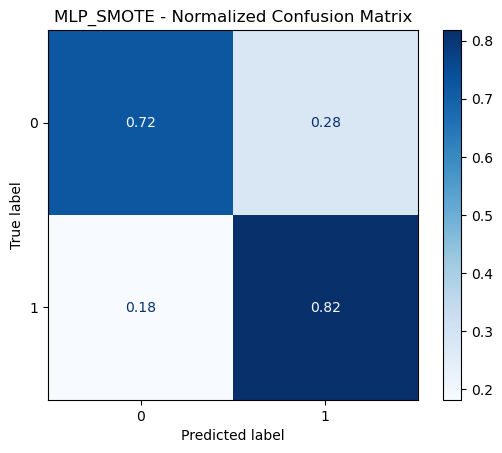

Classification Report:

              precision    recall  f1-score   support

         0.0      0.917     0.723     0.808      1035
         1.0      0.516     0.818     0.633       374

    accuracy                          0.748      1409
   macro avg      0.716     0.770     0.721      1409
weighted avg      0.810     0.748     0.762      1409


==== Evaluating ADA_SMOTE ====


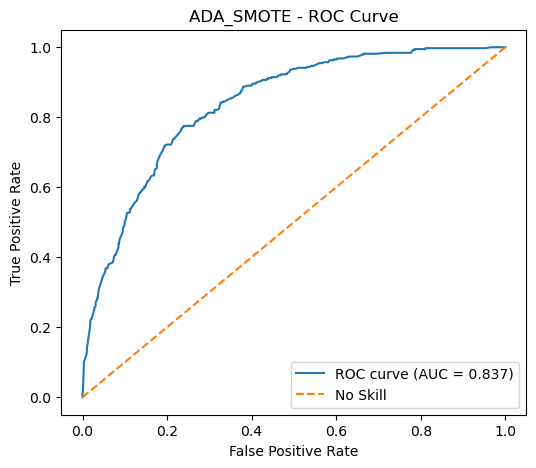

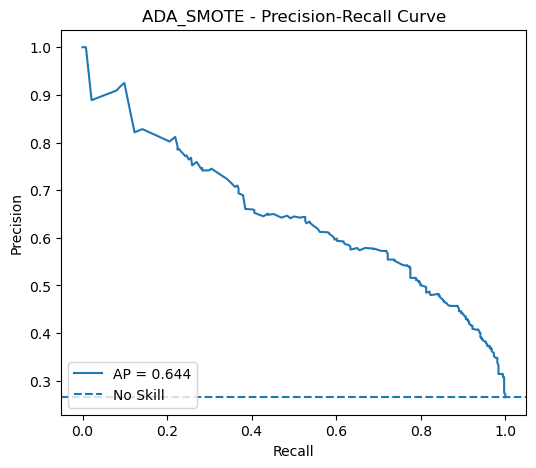

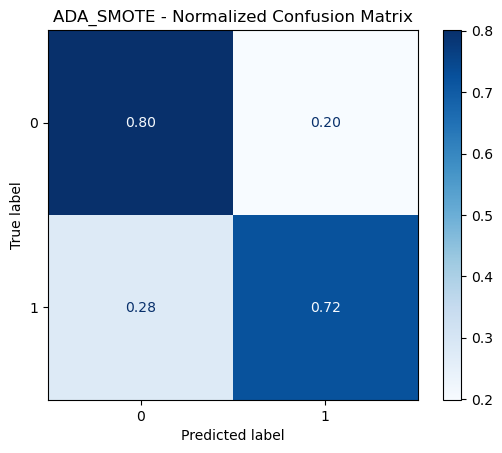

Classification Report:

              precision    recall  f1-score   support

         0.0      0.889     0.801     0.842      1035
         1.0      0.567     0.722     0.635       374

    accuracy                          0.780      1409
   macro avg      0.728     0.761     0.739      1409
weighted avg      0.803     0.780     0.787      1409



In [20]:
# ============================================================
# Model Evaluation and Visualisation (Corrected)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import numpy as np

for name, gs in grid_results.items():
    print(f"\n==== Evaluating {name} ====")
    best_model = gs.best_estimator_
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Scores for ROC / PR
    if hasattr(best_model, "predict_proba"):
        y_scores = best_model.predict_proba(X_test)[:, 1]
    elif hasattr(best_model, "decision_function"):
        y_scores = best_model.decision_function(X_test)
    else:
        y_scores = None
        print("Warning: No probability or decision scores available; skipping ROC/PR curves.")
    
    # --------------------
    # ROC Curve
    # --------------------
    if y_scores is not None:
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC Curve')
        plt.legend(loc='lower right')
        plt.show()
    
        # --------------------
        # Precision-Recall Curve
        # --------------------
        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        ap_score = average_precision_score(y_test, y_scores)
        
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f'AP = {ap_score:.3f}')
        plt.axhline(
            y=y_test.mean(),
            linestyle='--',
            label='No Skill'
        )
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} - Precision-Recall Curve')
        plt.legend(loc='lower left')
        plt.show()
    
    # --------------------
    # Confusion Matrix
    # --------------------
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap=plt.cm.Blues, values_format=".2f")
    plt.title(f'{name} - Normalized Confusion Matrix')
    plt.show()
    
    # --------------------
    # Classification Report
    # --------------------
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred, digits=3))



## Model comparison

- Compare classifier results in one plot using confusion matrix, ROC and Precision-Recall curves

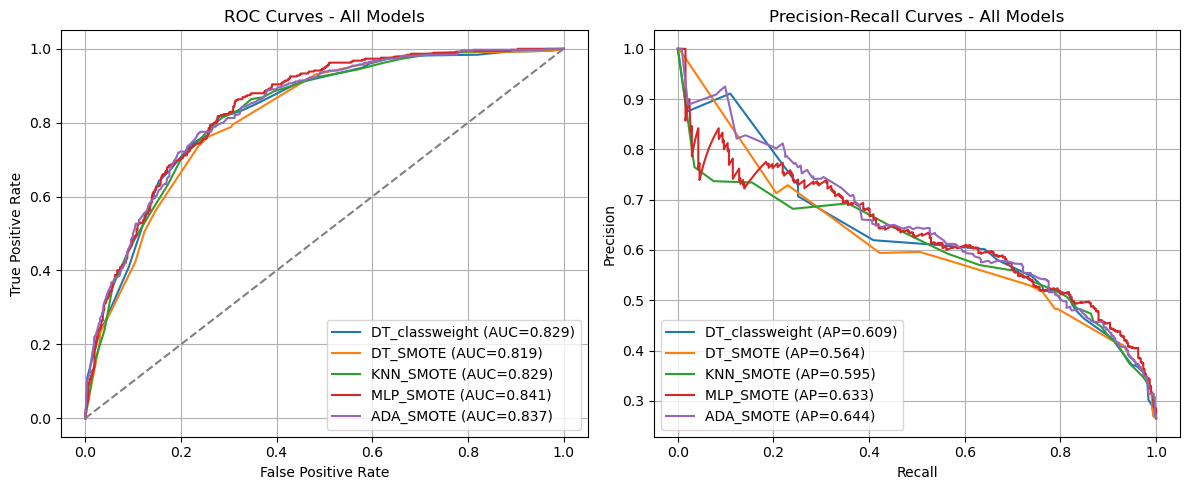

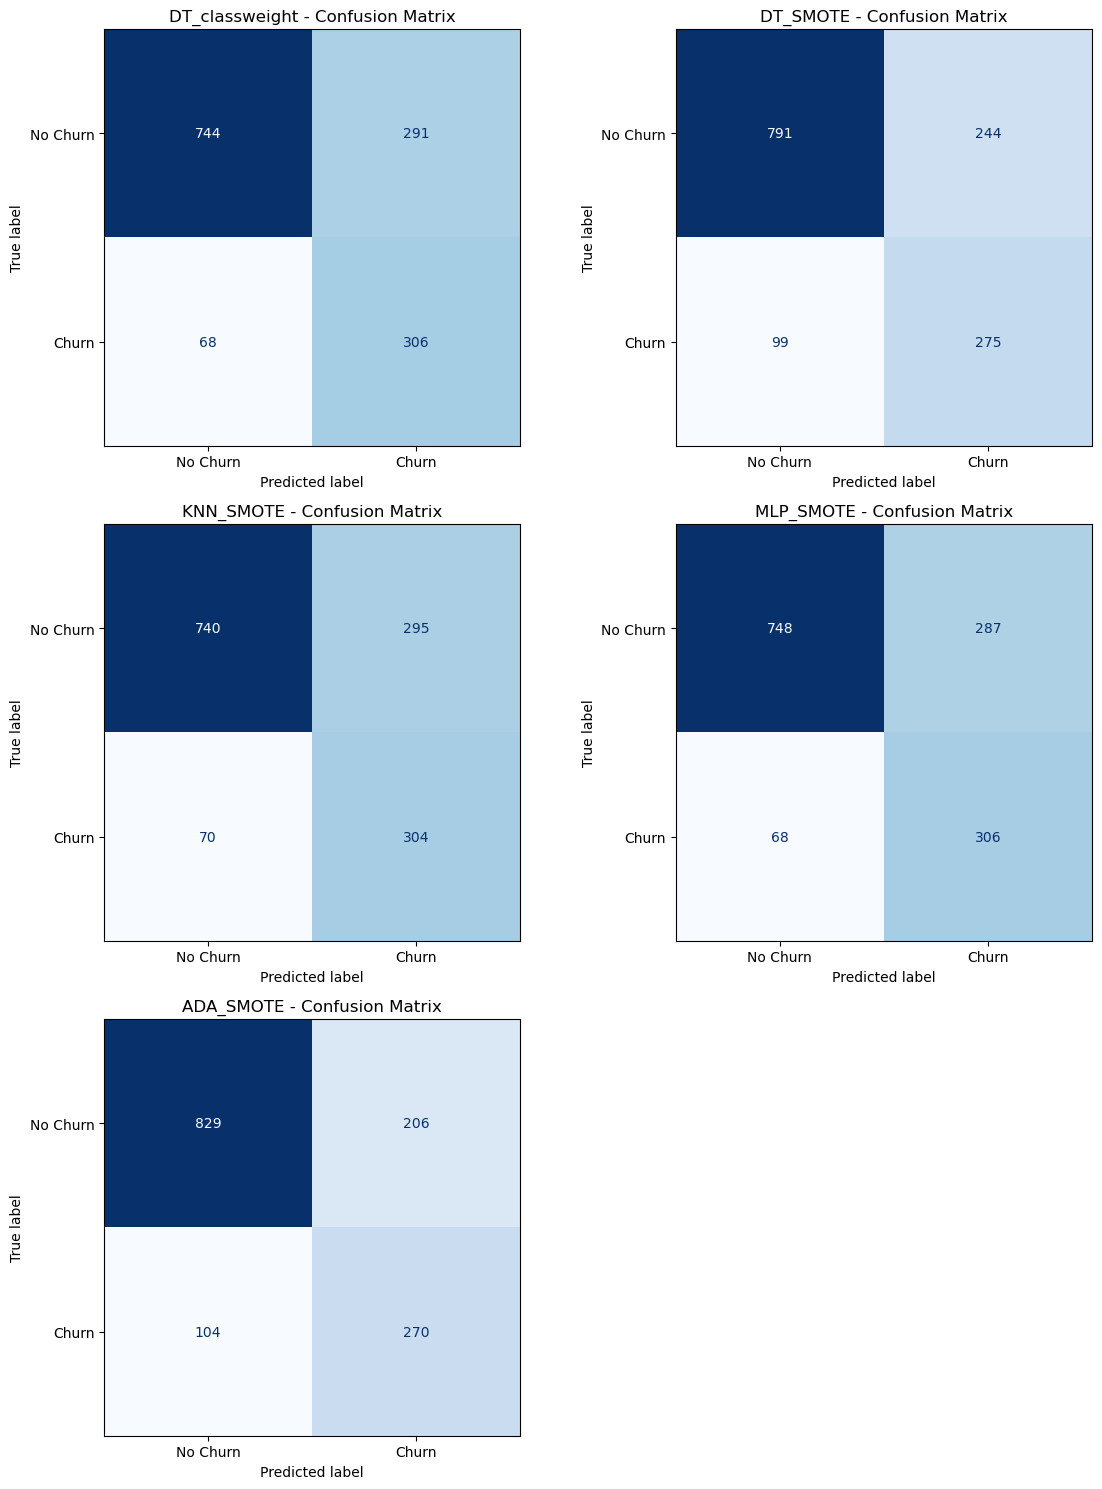

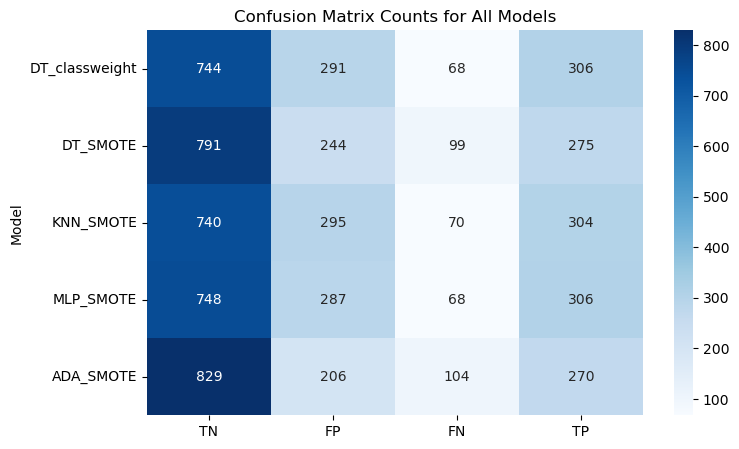

In [21]:
# ============================================================
# Combined ROC and Precision-Recall curves for all models
# ============================================================

plt.figure(figsize=(12,5))

# --------------------
# ROC Curves
# --------------------
plt.subplot(1,2,1)
for name, gs in grid_results.items():
    best_model = gs.best_estimator_
    if hasattr(best_model, "predict_proba"):
        y_probs = best_model.predict_proba(X_test)[:,1]
    else:
        y_probs = best_model.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True)

# --------------------
# Precision-Recall Curves
# --------------------
plt.subplot(1,2,2)
for name, gs in grid_results.items():
    best_model = gs.best_estimator_
    if hasattr(best_model, "predict_proba"):
        y_probs = best_model.predict_proba(X_test)[:,1]
    else:
        y_probs = best_model.predict(X_test)
    
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ap_score = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Number of models
n_models = len(grid_results)
n_cols = 2  # number of columns in the plot grid
n_rows = int(np.ceil(n_models / n_cols))

plt.figure(figsize=(6*n_cols, 5*n_rows))

for i, (name, gs) in enumerate(grid_results.items(), 1):
    best_model = gs.best_estimator_
    
    # Predict labels
    y_pred = best_model.predict(X_test)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot
    ax = plt.subplot(n_rows, n_cols, i)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
    ax.set_title(f'{name} - Confusion Matrix')

plt.tight_layout()
plt.show()

import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

cm_list = []

for name, gs in grid_results.items():
    y_pred = gs.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred).ravel()  # TN, FP, FN, TP
    cm_list.append([name] + list(cm))

# Create DataFrame
cm_df = pd.DataFrame(cm_list, columns=['Model', 'TN', 'FP', 'FN', 'TP']).set_index('Model')

plt.figure(figsize=(8,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Counts for All Models')
plt.show()


### Bar chart: Compare F1, precision and recall

/var/folders/r9/05xts64x6rn6tmq0yqn9m7xr0000gn/T/ipykernel_6329/1437032803.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_summary = pd.concat([metrics_summary,


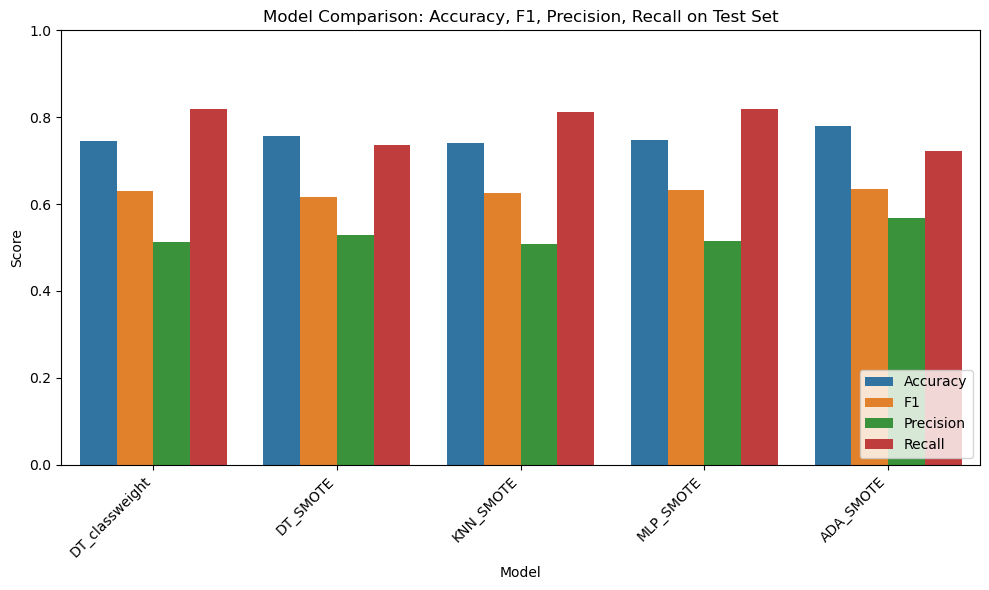

,Accuracy,F1,Precision,Recall
Model,,,,
ADA_SMOTE,0.779986,0.635294,0.567227,0.721925
MLP_SMOTE,0.748048,0.632885,0.516020,0.818182
DT_classweight,0.745209,0.630278,0.512563,0.818182
KNN_SMOTE,0.740951,0.624872,0.507513,0.812834
DT_SMOTE,0.756565,0.615901,0.529865,0.735294


In [22]:
# ============================================================
# Combined bar chart: Accuracy, F1-score, Precision, Recall per model
# ============================================================

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare metrics storage
metrics_summary = pd.DataFrame(columns=['Model', 'Accuracy', 'F1', 'Precision', 'Recall'])

for name, gs in grid_results.items():
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    metrics_summary = pd.concat([metrics_summary, 
                                 pd.DataFrame({'Model':[name],
                                               'Accuracy':[accuracy],
                                               'F1':[f1],
                                               'Precision':[precision],
                                               'Recall':[recall]})],
                                ignore_index=True)

# Melt dataframe for grouped bar plot
metrics_melted = metrics_summary.melt(id_vars='Model', 
                                      value_vars=['Accuracy','F1','Precision','Recall'], 
                                      var_name='Metric', 
                                      value_name='Score')

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted)
plt.ylim(0,1)
plt.title('Model Comparison: Accuracy, F1, Precision, Recall on Test Set')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Optional: display numeric summary
display(metrics_summary.set_index('Model').sort_values('F1', ascending=False))


### Visualise Decision tree

- allow model interpretation
- Provide Feature importance (relevant features in the tree for separation)

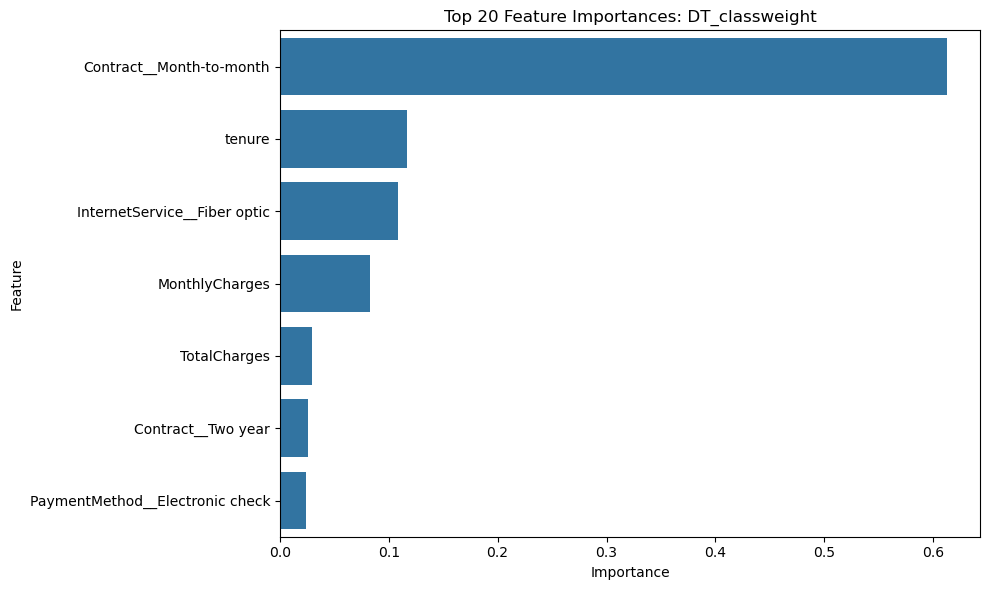

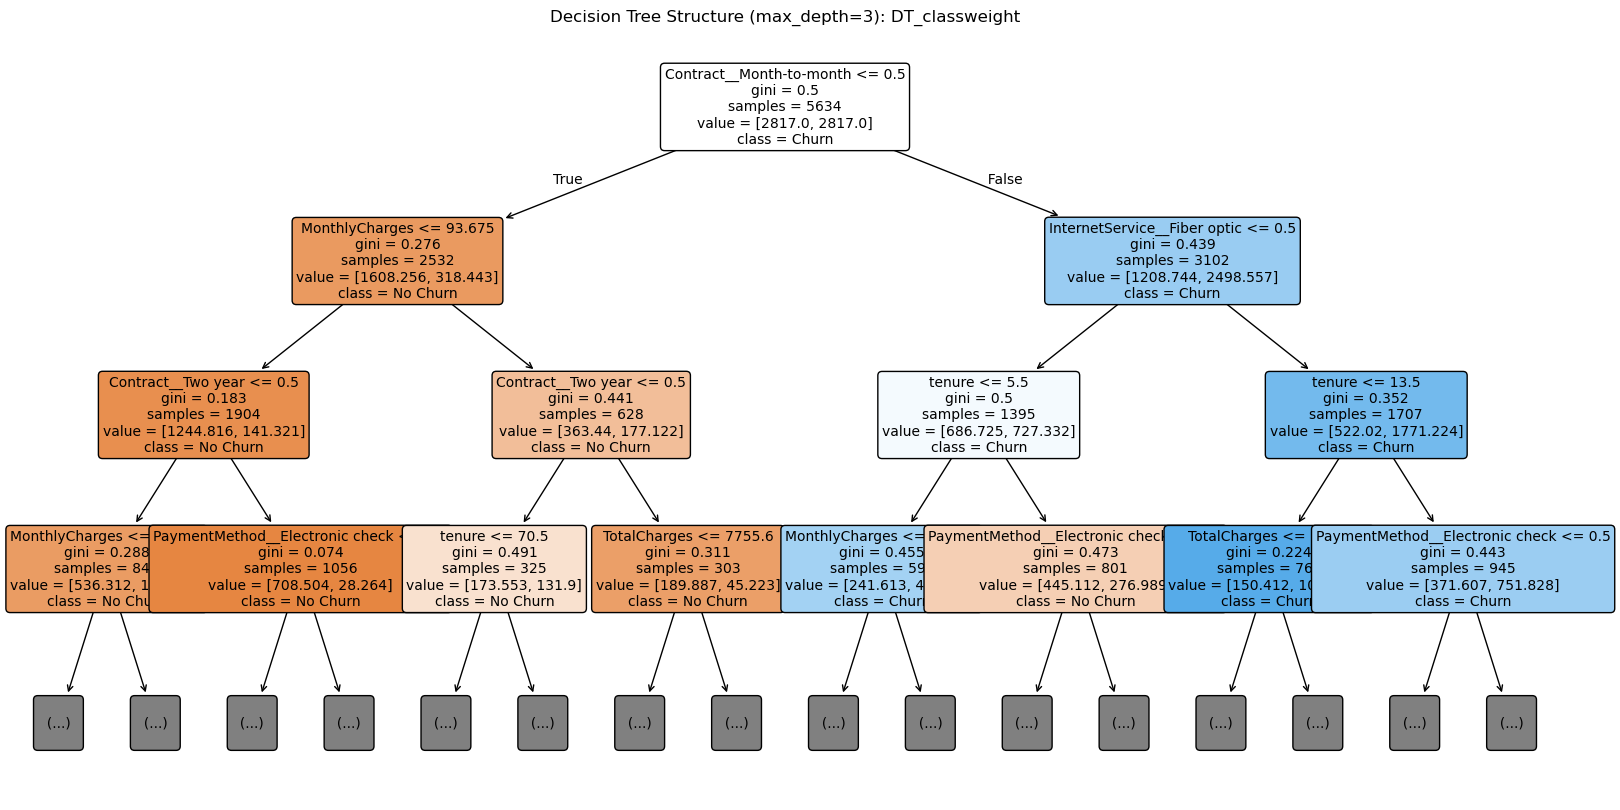

In [23]:
# ============================================================
# Decision Tree visualization & Feature Importance (updated)
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select the best Decision Tree model (adjust name if needed)
dt_model_name = 'DT_classweight'  # or 'DT_SMOTE'
best_dt = grid_results[dt_model_name].best_estimator_

# Extract trained classifier
clf = best_dt.named_steps['clf']

# Use the original dataset columns as feature names
# Replace X_train with your actual feature dataframe used for training
all_features = X_train.columns.tolist()  

# ---------------------------
# Feature importance plot
# ---------------------------
importances = clf.feature_importances_

feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title(f'Top 20 Feature Importances: {dt_model_name}')
plt.tight_layout()
plt.show()

# ---------------------------
# Optional: Decision Tree structure (first 3 levels)
# ---------------------------
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=all_features, class_names=['No Churn','Churn'], filled=True, rounded=True, max_depth=3,fontsize=10)
plt.title(f'Decision Tree Structure (max_depth=3): {dt_model_name}')
plt.show()

